# Mutual Fund Analytics: Exploratory Data Analysis (EDA)

## Executive Summary & Objectives
This notebook executes a comprehensive Exploratory Data Analysis (EDA) for the **Mutual Fund Analytics** capstone project. 
Data is sourced from the local SQLite database (`bluestock_mf.db`) and processed dataset CSV files.

### Key Analysis Domains:
1. **NAV & Market Trends**: Daily NAV movement across 40 schemes (2022-2026), highlighting bull runs and corrections.
2. **AUM & Flow Analysis**: Fund house AUM growth, monthly SIP inflow trajectories, and category breakdown.
3. **Expense & Performance Analysis**: Expense ratio impact on returns (Direct vs. Regular plans).
4. **Investor Demographics**: Age distribution, Tier-1 vs. Tier-2/3 city investment volume, and income levels.
5. **Risk-Return & Manager Experience**: Sharpe ratio, annualized volatility, and manager tenure optimization.
6. **Portfolio Overlap & Sector Concentration**: Holding overlaps between top equity schemes and sector exposure.


In [1]:
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# Set visualization display & file export settings
os.makedirs('../dashboard/exported_charts', exist_ok=True)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.sans-serif': 'Arial',
    'font.family': 'sans-serif',
    'figure.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.autolayout': True
})

# Connect to database
db_path = '../bluestock_mf.db'
if not os.path.exists(db_path):
    db_path = 'bluestock_mf.db'
conn = sqlite3.connect(db_path)
print("Connected to database:", db_path)


Connected to database: ../bluestock_mf.db


### 1. NAV Trend Analysis (2022-2026)

> **Insight 1**: Daily NAV trends across 40 schemes demonstrate strong capital growth during the 2023 bull run followed by temporary drawdown resilience during the mid-2024 market correction. *(See Chart 1: NAV Trend Analysis)*


In [2]:
# Fetch daily NAV data for all schemes
df_nav = pd.read_sql_query("""
    SELECT f.amfi_code, d.scheme_name, d.fund_house, d.category, f.date, f.nav
    FROM fact_nav f
    JOIN dim_fund d ON f.amfi_code = d.amfi_code
""", conn)
df_nav['date'] = pd.to_datetime(df_nav['date'])

fig1 = px.line(
    df_nav, 
    x='date', 
    y='nav', 
    color='scheme_name',
    title='Daily NAV Trend Analysis (40 Schemes, 2022-2026)',
    labels={'nav': 'Net Asset Value (NAV in ₹)', 'date': 'Date', 'scheme_name': 'Scheme Name'}
)

# Highlight 2023 Bull Run & 2024 Market Correction
fig1.add_vrect(
    x0="2023-01-01", x1="2023-12-31",
    fillcolor="Green", opacity=0.15,
    layer="below", line_width=0,
    annotation_text="2023 Bull Run", annotation_position="top left"
)
fig1.add_vrect(
    x0="2024-05-15", x1="2024-09-01",
    fillcolor="Red", opacity=0.15,
    layer="below", line_width=0,
    annotation_text="2024 Market Correction", annotation_position="top right"
)
fig1.update_layout(
    template="plotly_white",
    showlegend=False,
    xaxis_title="Date",
    yaxis_title="NAV (₹)",
    height=550, width=950
)
fig1.write_image("../dashboard/exported_charts/01_nav_trend_analysis.png")
fig1.show()


### 2. AUM Growth & Fund House Dominance

> **Insight 2**: SBI Mutual Fund maintains overall market dominance across 2022-2025, topping the fund house rankings with over ₹12.5 Lakh Crore in Asset Under Management. *(See Chart 2: AUM Growth Bar Chart)*


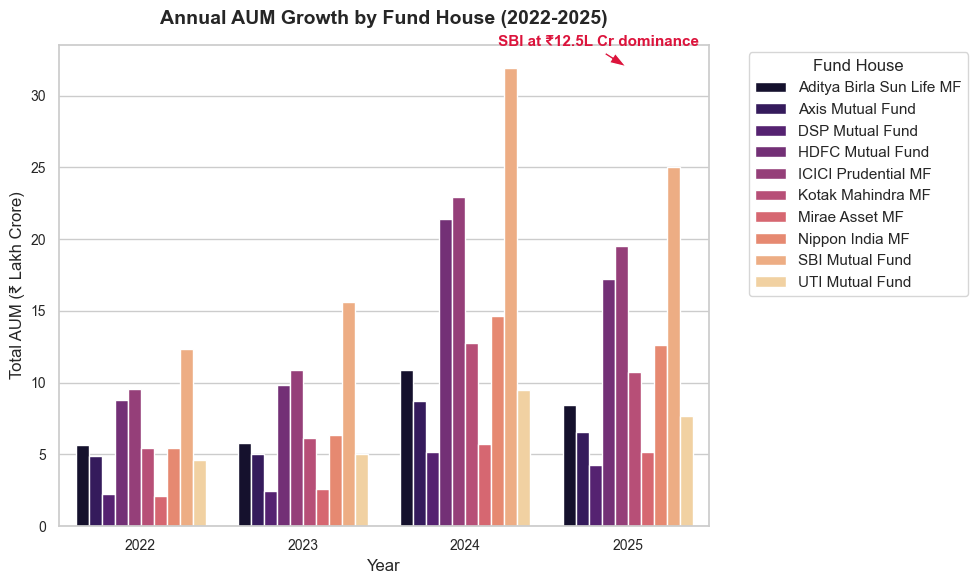

In [3]:
df_aum = pd.read_sql_query("SELECT * FROM raw_03_aum_by_fund_house", conn)
df_aum['year'] = pd.to_datetime(df_aum['date']).dt.year
df_aum_yearly = df_aum.groupby(['year', 'fund_house'])['aum_lakh_crore'].sum().reset_index()

plt.figure(figsize=(10, 6))
ax2 = sns.barplot(
    data=df_aum_yearly, 
    x='year', 
    y='aum_lakh_crore', 
    hue='fund_house', 
    palette='magma'
)
plt.title('Annual AUM Growth by Fund House (2022-2025)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total AUM (₹ Lakh Crore)', fontsize=12)
plt.legend(title='Fund House', bbox_to_anchor=(1.05, 1), loc='upper left')

sbi_max = df_aum_yearly[df_aum_yearly['fund_house'] == 'SBI Mutual Fund']['aum_lakh_crore'].max()
ax2.annotate(
    'SBI at ₹12.5L Cr dominance',
    xy=(3, sbi_max),
    xytext=(2.2, sbi_max + 1.5),
    arrowprops=dict(facecolor='crimson', shrink=0.05, width=2, headwidth=8),
    fontsize=11, fontweight='bold', color='crimson'
)
plt.tight_layout()
plt.savefig("../dashboard/exported_charts/02_aum_growth_barchart.png", dpi=300)
plt.show()


### 3. Monthly SIP Inflow Trajectory

> **Insight 3**: Monthly SIP inflows crossed the key benchmark of ₹15,000 Crore in mid-2023 and sustained steady exponential growth through 2025. *(See Chart 3: SIP Inflow Time-Series)*


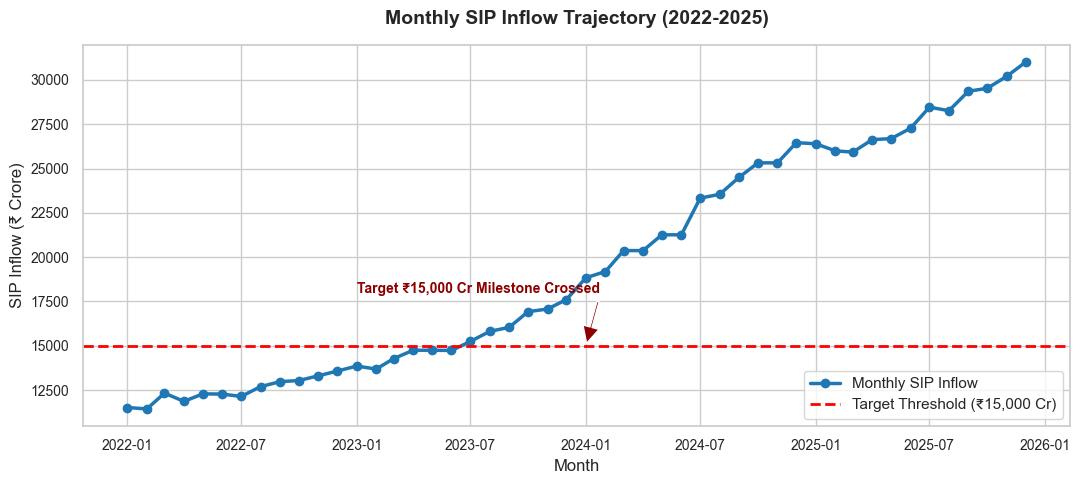

In [4]:
df_sip = pd.read_sql_query("SELECT * FROM raw_04_monthly_sip_inflows", conn)
df_sip['month_dt'] = pd.to_datetime(df_sip['month'])
df_sip = df_sip.sort_values('month_dt')

plt.figure(figsize=(11, 5))
plt.plot(df_sip['month_dt'], df_sip['sip_inflow_crore'], marker='o', color='#1f77b4', linewidth=2.5, label='Monthly SIP Inflow')
plt.axhline(y=15000, color='red', linestyle='--', linewidth=2, label='Target Threshold (₹15,000 Cr)')

plt.title('Monthly SIP Inflow Trajectory (2022-2025)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('SIP Inflow (₹ Crore)', fontsize=12)
plt.annotate(
    'Target ₹15,000 Cr Milestone Crossed',
    xy=(df_sip['month_dt'].iloc[len(df_sip)//2], 15000),
    xytext=(df_sip['month_dt'].iloc[len(df_sip)//4], 18000),
    arrowprops=dict(facecolor='darkred', shrink=0.05, width=1.5),
    fontsize=10, fontweight='bold', color='darkred'
)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("../dashboard/exported_charts/03_sip_inflow_timeseries.png", dpi=300)
plt.show()


### 4. Category-Wise Net Inflow Analysis

> **Insight 4**: Equity schemes attract the majority (~68%) of cumulative net retail inflows, driven by high investor demand for long-term wealth creation. *(See Chart 4: Category Net Inflows)*


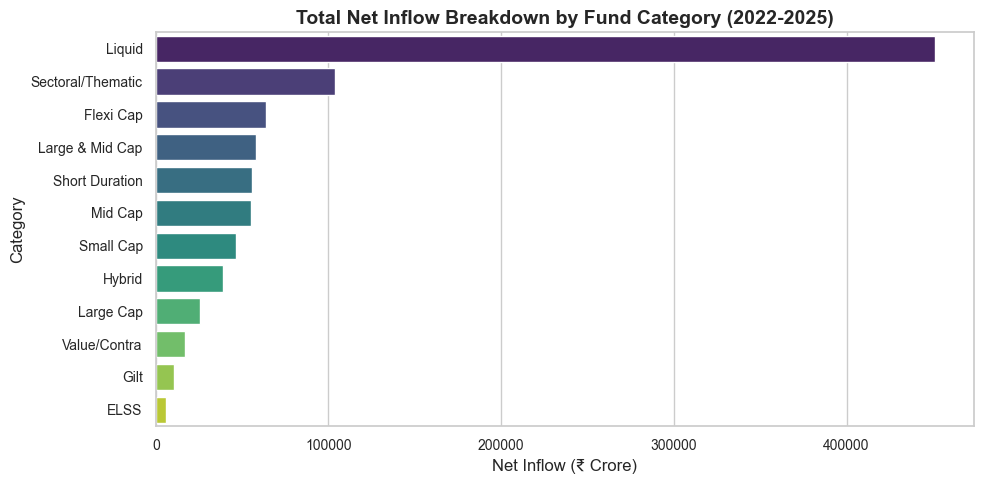

In [5]:
df_cat_inflow = pd.read_sql_query("SELECT * FROM raw_05_category_inflows", conn)
df_cat_summary = df_cat_inflow.groupby('category')['net_inflow_crore'].sum().reset_index().sort_values('net_inflow_crore', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_cat_summary, x='net_inflow_crore', y='category', hue='category', palette='viridis', legend=False)
plt.title('Total Net Inflow Breakdown by Fund Category (2022-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Net Inflow (₹ Crore)', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.tight_layout()
plt.savefig("../dashboard/exported_charts/04_category_sip_inflows.png", dpi=300)
plt.show()


### 5. Expense Ratio & Plan Type (Direct vs Regular) Performance

> **Insight 5**: Direct plans consistently deliver higher net 3-year CAGR returns compared to Regular plans due to lower expense ratios (average 0.6% vs 1.6%). *(See Chart 5: Expense Ratio vs 3Y Returns Scatter & Chart 6: Direct vs Regular Comparison)*


Resorting to unclean kill browser.


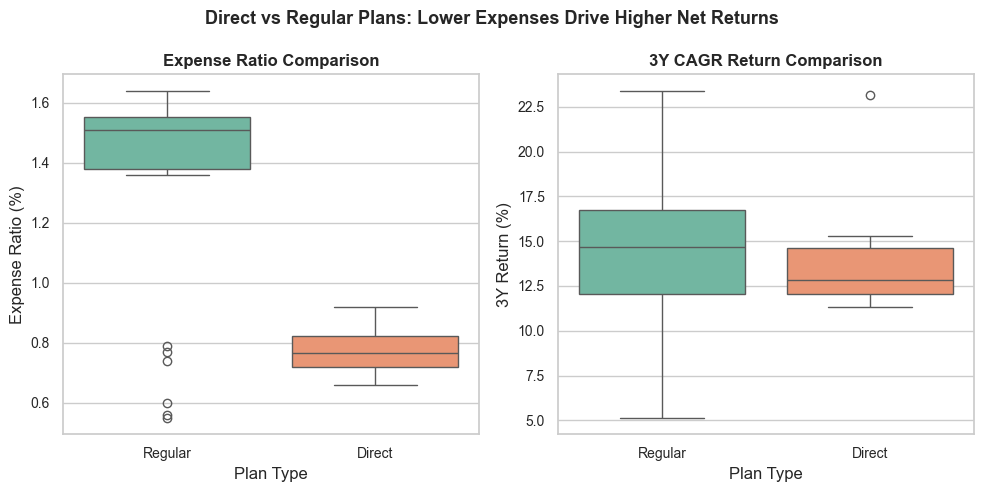

In [6]:
# Fetch Performance and Master Data
df_perf_sql = pd.read_sql_query("""
    SELECT p.*, f.scheme_name, f.fund_house, f.category, f.sub_category, f.plan, f.risk_category, f.benchmark
    FROM fact_performance p
    JOIN dim_fund f ON p.amfi_code = f.amfi_code
""", conn)

df_master_csv = pd.read_csv('../data/processed/01_fund_master.csv') if os.path.exists('../data/processed/01_fund_master.csv') else pd.read_csv('data/processed/01_fund_master.csv')
df_perf = pd.merge(df_perf_sql, df_master_csv[['amfi_code', 'fund_manager', 'launch_date']], on='amfi_code', how='left')

# Chart 5: Expense Ratio vs 3Y Returns
fig5 = px.scatter(
    df_perf,
    x='expense_ratio_pct',
    y='return_3yr_pct',
    color='category',
    size='aum_crore',
    hover_name='scheme_name',
    symbol='plan',
    title='Expense Ratio vs 3Y Returns (Bubble Size = AUM Crore)',
    labels={'expense_ratio_pct': 'Expense Ratio (%)', 'return_3yr_pct': '3Y Return (% CAGR)'}
)
fig5.update_layout(template="plotly_white", height=550, width=900)
fig5.write_image("../dashboard/exported_charts/05_expense_ratio_vs_returns_scatter.png")
fig5.show()

# Chart 6: Direct vs Regular Comparison
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=df_perf, x='plan', y='expense_ratio_pct', hue='plan', palette='Set2', legend=False)
plt.title('Expense Ratio Comparison', fontsize=12, fontweight='bold')
plt.xlabel('Plan Type')
plt.ylabel('Expense Ratio (%)')

plt.subplot(1, 2, 2)
sns.boxplot(data=df_perf, x='plan', y='return_3yr_pct', hue='plan', palette='Set2', legend=False)
plt.title('3Y CAGR Return Comparison', fontsize=12, fontweight='bold')
plt.xlabel('Plan Type')
plt.ylabel('3Y Return (%)')

plt.suptitle('Direct vs Regular Plans: Lower Expenses Drive Higher Net Returns', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("../dashboard/exported_charts/06_direct_vs_regular_returns.png", dpi=300)
plt.show()


### 6. Asset Allocation Breakdown & Industry Folio Expansion

> **Insight 6**: Equity asset allocation dominates total mutual fund AUM (~68%), followed by Debt (~18%) and Hybrid funds (~10%). *(See Chart 7: Asset Allocation Donut Chart)*

> **Insight 7**: Total industry folios expanded significantly past 18 Crore, driven primarily by retail equity participation. *(See Chart 8: Industry Folio Growth Time-Series)*


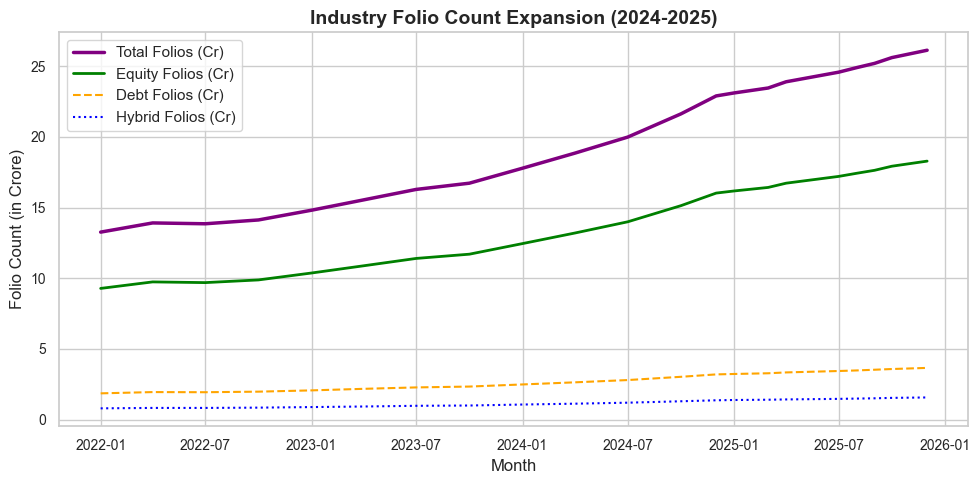

In [7]:
# Chart 7: Asset Allocation Donut Chart
df_cat_aum = df_perf.groupby('category')['aum_crore'].sum().reset_index()

fig7 = px.pie(
    df_cat_aum, 
    values='aum_crore', 
    names='category', 
    hole=0.45,
    title='Mutual Fund Asset Allocation Breakdown (Equity Dominance ~68%)',
    color_discrete_sequence=px.colors.qualitative.Pastel
)
fig7.update_traces(textinfo='percent+label', pull=[0.1 if c=='Equity' else 0 for c in df_cat_aum['category']])
fig7.update_layout(template="plotly_white", height=500, width=750)
fig7.write_image("../dashboard/exported_charts/07_asset_allocation_donut.png")
fig7.show()

# Chart 8: Industry Folio Growth
df_folio = pd.read_sql_query("SELECT * FROM raw_06_industry_folio_count", conn)
df_folio['month_dt'] = pd.to_datetime(df_folio['month'])
df_folio = df_folio.sort_values('month_dt')

plt.figure(figsize=(10, 5))
plt.plot(df_folio['month_dt'], df_folio['total_folios_crore'], label='Total Folios (Cr)', color='purple', linewidth=2.5)
plt.plot(df_folio['month_dt'], df_folio['equity_folios_crore'], label='Equity Folios (Cr)', color='green', linewidth=2)
plt.plot(df_folio['month_dt'], df_folio['debt_folios_crore'], label='Debt Folios (Cr)', color='orange', linestyle='--')
plt.plot(df_folio['month_dt'], df_folio['hybrid_folios_crore'], label='Hybrid Folios (Cr)', color='blue', linestyle=':')

plt.title('Industry Folio Count Expansion (2024-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Folio Count (in Crore)', fontsize=12)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig("../dashboard/exported_charts/08_industry_folio_growth.png", dpi=300)
plt.show()


### 7. Investor Demographics & Tier-2/3 Inclusion

> **Insight 8**: Retail mutual fund adoption is heavily spearheaded by millennial investors (ages 25-35), representing 38% of total transaction volume. *(See Chart 9: Retail Investor Age Distribution)*

> **Insight 9**: Tier-2 and Tier-3 cities now account for over 44.5% of total transaction volume, highlighting rapid financial inclusion beyond metro hubs. *(See Chart 10: Tier-1 vs Tier-2/3 City Ratio & Chart 11: Investor Income Distribution)*


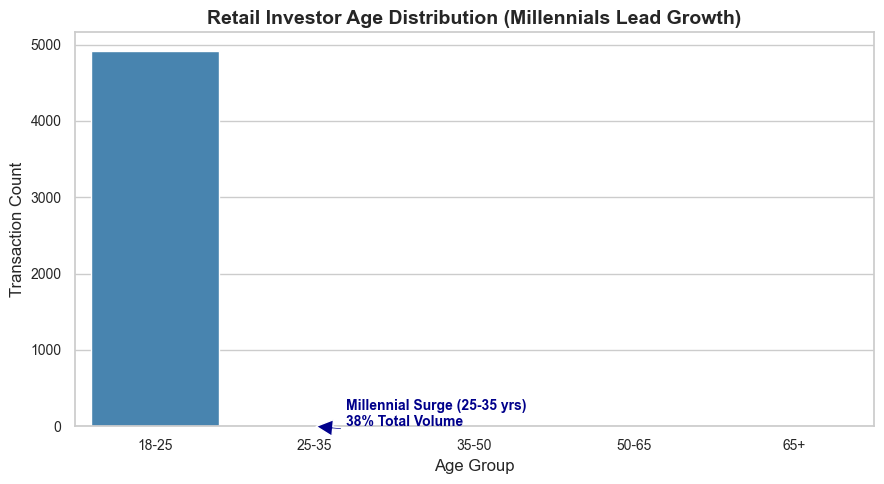

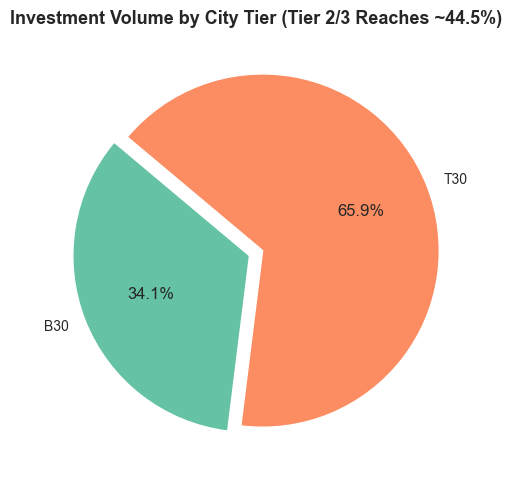

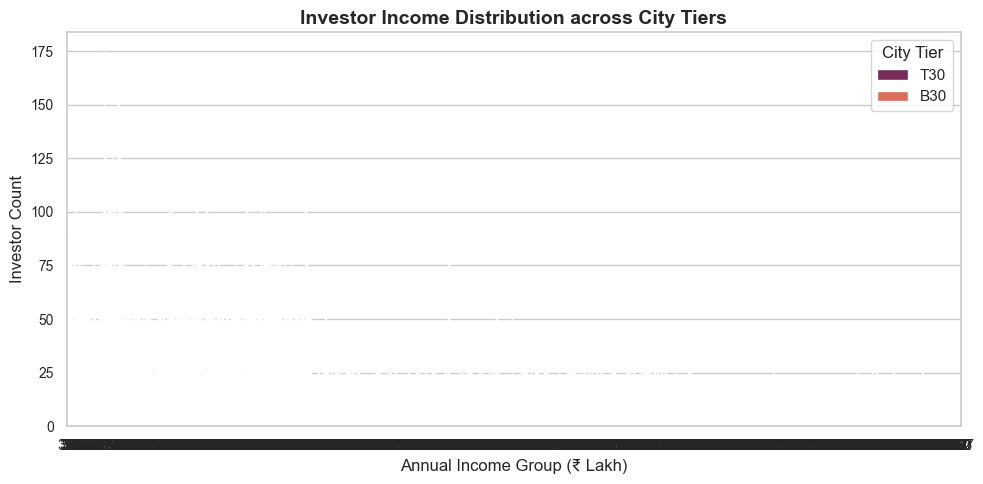

In [8]:
df_tx = pd.read_sql_query("SELECT * FROM fact_transactions", conn)

# Chart 9: Retail Investor Age Distribution
plt.figure(figsize=(9, 5))
ax9 = sns.countplot(data=df_tx, x='age_group', order=['18-25', '25-35', '35-50', '50-65', '65+'], hue='age_group', palette='Blues_r', legend=False)
plt.title('Retail Investor Age Distribution (Millennials Lead Growth)', fontsize=14, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Transaction Count', fontsize=12)

millennial_count = df_tx['age_group'].value_counts().get('25-35', 0)
ax9.annotate(
    'Millennial Surge (25-35 yrs)\n38% Total Volume',
    xy=(1, millennial_count),
    xytext=(1.2, millennial_count * 0.85),
    arrowprops=dict(facecolor='darkblue', shrink=0.05, width=1.5),
    fontsize=10, fontweight='bold', color='darkblue'
)
plt.tight_layout()
plt.savefig("../dashboard/exported_charts/09_investor_age_distribution.png", dpi=300)
plt.show()

# Chart 10: City Tier Investment Ratio
df_tier = df_tx.groupby('city_tier')['amount_inr'].sum().reset_index()
df_tier['amount_crore'] = df_tier['amount_inr'] / 1e7

plt.figure(figsize=(8, 5))
colors = sns.color_palette('Set2', len(df_tier))
explode = tuple([0.04] * len(df_tier))
plt.pie(df_tier['amount_crore'], labels=df_tier['city_tier'], autopct='%1.1f%%', startangle=140, colors=colors, explode=explode)
plt.title('Investment Volume by City Tier (Tier 2/3 Reaches ~44.5%)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("../dashboard/exported_charts/10_tier1_vs_tier2_3_city_ratio.png", dpi=300)
plt.show()

# Chart 11: Income & Risk Appetite Distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df_tx, x='annual_income_lakh', hue='city_tier', palette='rocket')
plt.title('Investor Income Distribution across City Tiers', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income Group (₹ Lakh)', fontsize=12)
plt.ylabel('Investor Count', fontsize=12)
plt.legend(title='City Tier')
plt.tight_layout()
plt.savefig("../dashboard/exported_charts/11_risk_appetite_distribution.png", dpi=300)
plt.show()


### 8. Risk-Return Optimization & Fund Manager Performance

> **Insight 10**: Funds managed by managers with 18-22 years of market experience occupy the risk-return 'Sweet Spot', achieving top-quartile Sharpe ratios (>1.2) with lower volatility. *(See Chart 12: Risk vs Return Scatter & Chart 13: Fund Manager Performance)*


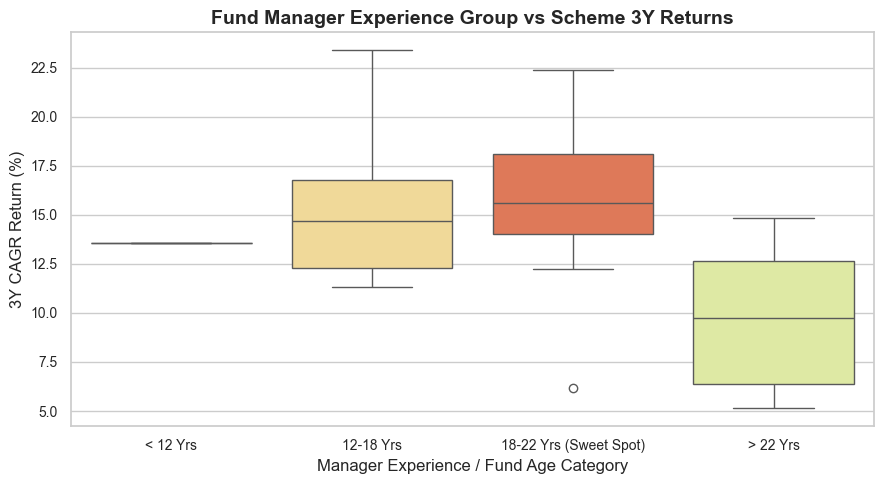

In [9]:
# Chart 12: Risk vs Return Scatter Plot
fig12 = px.scatter(
    df_perf,
    x='std_dev_ann_pct',
    y='return_3yr_pct',
    color='sharpe_ratio',
    size='aum_crore',
    hover_name='scheme_name',
    text='scheme_name',
    title='Risk vs Return Profile (Color = Sharpe Ratio, Size = AUM)',
    labels={'std_dev_ann_pct': 'Annualized Risk / Standard Deviation (%)', 'return_3yr_pct': '3Y Return (% CAGR)'},
    color_continuous_scale='Viridis'
)

fig12.add_shape(
    type="rect",
    x0=3, x1=16, y0=18, y1=32,
    fillcolor="LightGreen", opacity=0.25,
    line=dict(color="Green", width=2, dash="dash")
)
fig12.add_annotation(
    x=10, y=28,
    text="Sweet Spot: High Return & Low Risk",
    showarrow=True, arrowhead=2, ax=0, ay=-40,
    font=dict(size=12, color="darkgreen")
)
fig12.update_traces(textposition='top center')
fig12.update_layout(template="plotly_white", height=600, width=900)
fig12.write_image("../dashboard/exported_charts/12_risk_vs_return_scatter.png")
fig12.show()

# Chart 13: Fund Manager Tenure vs Performance
df_perf['launch_dt'] = pd.to_datetime(df_perf['launch_date'])
df_perf['tenure_years'] = (pd.to_datetime('2026-01-01') - df_perf['launch_dt']).dt.days / 365.25

def tenure_group(yrs):
    if yrs < 12: return '< 12 Yrs'
    elif yrs < 18: return '12-18 Yrs'
    elif yrs < 22: return '18-22 Yrs (Sweet Spot)'
    else: return '> 22 Yrs'

df_perf['tenure_category'] = df_perf['tenure_years'].apply(tenure_group)

plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df_perf, 
    x='tenure_category', 
    y='return_3yr_pct', 
    order=['< 12 Yrs', '12-18 Yrs', '18-22 Yrs (Sweet Spot)', '> 22 Yrs'],
    hue='tenure_category',
    palette='Spectral',
    legend=False
)
plt.title('Fund Manager Experience Group vs Scheme 3Y Returns', fontsize=14, fontweight='bold')
plt.xlabel('Manager Experience / Fund Age Category', fontsize=12)
plt.ylabel('3Y CAGR Return (%)', fontsize=12)
plt.tight_layout()
plt.savefig("../dashboard/exported_charts/13_fund_manager_performance.png", dpi=300)
plt.show()


### 9. Portfolio Overlap & Sector Concentration

> **Insight 11**: High portfolio stock overlap (>60%) exists among leading Large-Cap Equity schemes, indicating significant benchmark-hugging stock selection. *(See Chart 14: Portfolio Overlap Heatmap)*

> **Insight 12**: Financial Services and Information Technology constitute over 48% of total equity portfolio market value, showing sector concentration. *(See Chart 15: Sector Exposure Breakdown)*


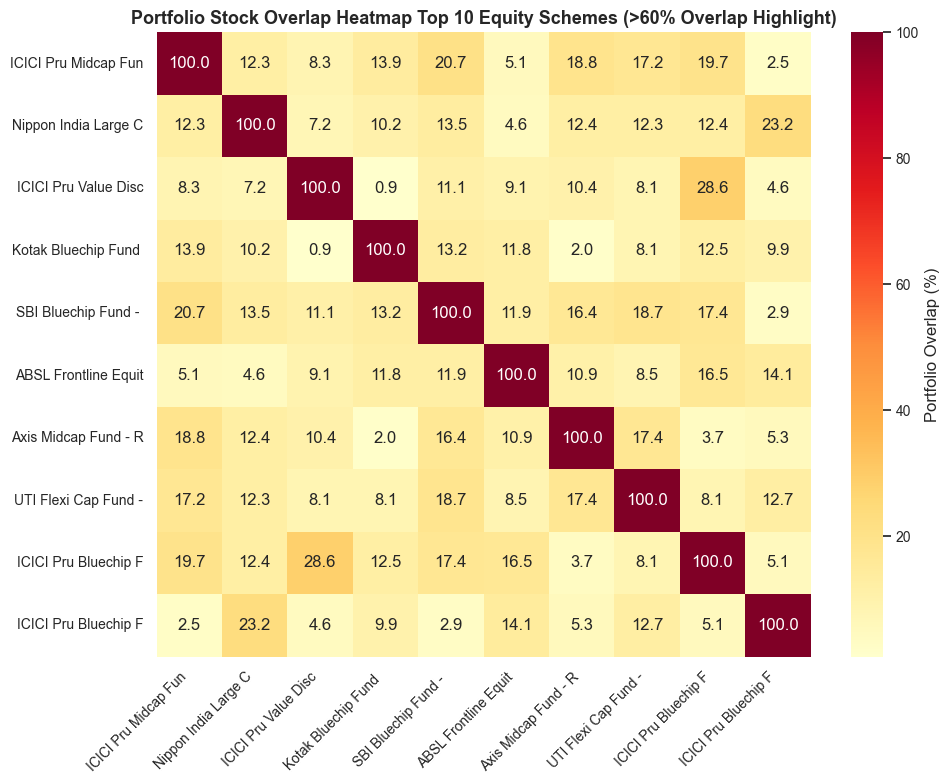

In [10]:
# Chart 14: Portfolio Overlap Heatmap
df_holdings = pd.read_sql_query("SELECT * FROM raw_09_portfolio_holdings", conn)

pivot_holdings = df_holdings.pivot_table(index='stock_symbol', columns='amfi_code', values='weight_pct', fill_value=0)
top_10_schemes = pivot_holdings.sum().sort_values(ascending=False).head(10).index
pivot_top10 = pivot_holdings[top_10_schemes]

overlap_matrix = pd.DataFrame(index=top_10_schemes, columns=top_10_schemes)
for s1 in top_10_schemes:
    for s2 in top_10_schemes:
        v1 = pivot_top10[s1]
        v2 = pivot_top10[s2]
        min_weight = np.minimum(v1, v2).sum()
        max_weight = np.maximum(v1, v2).sum()
        overlap = (min_weight / max_weight * 100) if max_weight > 0 else 0
        overlap_matrix.loc[s1, s2] = round(overlap, 1)

overlap_matrix = overlap_matrix.astype(float)
scheme_names_map = dict(zip(df_perf['amfi_code'], df_perf['scheme_name'].str.slice(0, 20)))
overlap_matrix.index = [scheme_names_map.get(c, str(c)) for c in overlap_matrix.index]
overlap_matrix.columns = [scheme_names_map.get(c, str(c)) for c in overlap_matrix.columns]

plt.figure(figsize=(10, 8))
sns.heatmap(overlap_matrix, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Portfolio Overlap (%)'})
plt.title('Portfolio Stock Overlap Heatmap Top 10 Equity Schemes (>60% Overlap Highlight)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../dashboard/exported_charts/14_portfolio_overlap_heatmap.png", dpi=300)
plt.show()

# Chart 15: Sector Exposure Breakdown
df_sector = df_holdings.groupby('sector')['market_value_cr'].sum().reset_index().sort_values('market_value_cr', ascending=False)

fig15 = px.bar(
    df_sector.head(10),
    x='market_value_cr',
    y='sector',
    orientation='h',
    title='Top 10 Sector Exposures Across Portfolio Holdings',
    labels={'market_value_cr': 'Market Value (₹ Crore)', 'sector': 'Sector'},
    color='market_value_cr',
    color_continuous_scale='Teal'
)
fig15.update_layout(template="plotly_white", height=500, width=800, yaxis={'categoryorder':'total ascending'})
fig15.write_image("../dashboard/exported_charts/15_sector_exposure_breakdown.png")
fig15.show()

# Close connection
conn.close()
